#  Deepfake Detection — Final Pipeline
### FaceForensics++ C23 — Deepfakes vs Original

| Stage | Description |
|-------|-------------|
| **S1** | Frame extraction (GPU ffmpeg, 1 call per video) + MobileNetV3 CNN |
| **S2** | Facial region segmentation (eyes/mouth/cheeks) + EfficientNet-B0 |
| **S3** | Temporal GRU adaptive loop until all metrics > 85% |

>  **Enable GPU first:** Runtime → Change runtime type → **T4 GPU**
>
> **For Section 1A:** Run either **1A-1** (all videos) OR **1A-2** (subsample). Skip the other.

##  CELL 0 — Installs & Setup

In [ ]:
!pip install kagglehub timm scikit-learn -q

import os, json, shutil, cv2, random, warnings, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import timm
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

BASE = Path('/content/outputs')
DIRS = {
    'frames':        BASE / 'frames',
    'splits':        BASE / 'splits',
    'models':        BASE / 'models',
    'metrics':       BASE / 'metrics',
    'regions':       BASE / 'regions',
    'temporal':      BASE / 'temporal',
    'temporal_best': BASE / 'temporal/best_run',
    'final':         BASE / 'final',
}
for d in DIRS.values(): d.mkdir(parents=True, exist_ok=True)

# ── Shared classes used across all sections ───────────────────────────────
class FrameDS(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.tf = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        r   = self.df.iloc[i]
        img = cv2.imread(r.path)
        if img is None: img = np.zeros((224,224,3), dtype=np.uint8)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.tf(img), int(r.label)

def evaluate(model, loader):
    model.eval()
    preds, probs, targets = [], [], []
    with torch.no_grad():
        for x, y in loader:
            with autocast('cuda'):
                out = torch.softmax(model(x.to(DEVICE)), dim=1)
            preds   += out.argmax(1).cpu().tolist()
            probs   += out[:,1].cpu().tolist()
            targets += y.tolist()
    try:
        auc = roc_auc_score(targets, probs)
    except ValueError:
        auc = 0.5
    return {
        'accuracy':  round(accuracy_score(targets, preds), 4),
        'precision': round(precision_score(targets, preds, zero_division=0), 4),
        'recall':    round(recall_score(targets, preds, zero_division=0), 4),
        'auc':       round(auc, 4)
    }

print(' Setup complete')

Device: cuda
✅ Setup complete


##  CELL 0B — Download FF-C23 from Kaggle

In [ ]:
import os
os.environ['KAGGLE_TOKEN'] = 'paste token here, to use and import dataset.'

import kagglehub
path = kagglehub.dataset_download('xdxd003/ff-c23')
shutil.copytree(path, '/content/ff_c23', dirs_exist_ok=True)

REAL_VIDS = Path('/content/ff_c23/FaceForensics++_C23/original')
FAKE_VIDS = Path('/content/ff_c23/FaceForensics++_C23/Deepfakes')
assert REAL_VIDS.exists(), f' Not found: {REAL_VIDS}'
assert FAKE_VIDS.exists(), f' Not found: {FAKE_VIDS}'
print('Real videos:', len(list(REAL_VIDS.glob('*.mp4'))))
print('Fake videos:', len(list(FAKE_VIDS.glob('*.mp4'))))

Using Colab cache for faster access to the 'ff-c23' dataset.
Real videos: 1000
Fake videos: 1000


---
##  SECTION 1 — Frame Extraction + CNN Training

###  Run ONE of 1A-1 or 1A-2, then continue from 1A-3
| | Method | Use when |
|---|---|---|
| **1A-1** | All videos, GPU ffmpeg | Full experiment |
| **1A-2** | Subsample N per class, GPU ffmpeg | Quick prototype |

### CELL 1A-1 — GPU Extraction, All Videos
>  Skip if using 1A-2

In [ ]:
# CELL 1A-1 — All videos, one ffmpeg call per video
N_FRAMES = 20

def get_duration(vid_path):
    r = subprocess.run(['ffprobe','-v','error','-show_entries','format=duration',
                        '-of','csv=p=0', str(vid_path)], capture_output=True, text=True)
    try: return float(r.stdout.strip())
    except: return 0.0

def extract_gpu(vid_path, out_dir, label, n=N_FRAMES):
    out_dir.mkdir(parents=True, exist_ok=True)
    duration = get_duration(vid_path)
    if duration == 0: return []
    fps = n / duration
    cmd = ['ffmpeg','-loglevel','error','-hwaccel','cuda',
           '-i', str(vid_path),
           '-vf', f'fps={fps},scale=224:224',
           '-vframes', str(n), '-q:v', '2',
           str(out_dir / f'{vid_path.stem}_%03d.jpg'), '-y']
    subprocess.run(cmd, capture_output=True)
    rows = []
    for f in sorted(out_dir.glob(f'{vid_path.stem}_*.jpg'))[:n]:
        rows.append({'path': str(f), 'label': label, 'video_id': vid_path.stem})
    return rows

tasks = (
    [(v, DIRS['frames']/'real'/v.stem, 0) for v in sorted(REAL_VIDS.glob('*.mp4'))] +
    [(v, DIRS['frames']/'fake'/v.stem, 1) for v in sorted(FAKE_VIDS.glob('*.mp4'))]
)
print(f'Total videos: {len(tasks)}')

records = []
with ThreadPoolExecutor(max_workers=8) as ex:
    futures = {ex.submit(extract_gpu, *t): t for t in tasks}
    done = 0
    for f in as_completed(futures):
        records.extend(f.result())
        done += 1
        if done % 100 == 0: print(f'  {done}/{len(tasks)} | {len(records)} frames')

df = pd.DataFrame(records)
df.to_csv(DIRS['splits']/'frames.csv', index=False)
print(f'\n 1A-1 done: {len(df)} frames')
print(df.groupby('label').size())

Total videos: 2000
  100/2000 | 2000 frames
  200/2000 | 4000 frames
  300/2000 | 6000 frames
  400/2000 | 8000 frames
  500/2000 | 10000 frames
  600/2000 | 12000 frames
  700/2000 | 14000 frames
  800/2000 | 16000 frames
  900/2000 | 18000 frames
  1000/2000 | 20000 frames
  1100/2000 | 22000 frames
  1200/2000 | 24000 frames
  1300/2000 | 26000 frames
  1400/2000 | 28000 frames
  1500/2000 | 30000 frames
  1600/2000 | 32000 frames
  1700/2000 | 34000 frames
  1800/2000 | 36000 frames
  1900/2000 | 38000 frames
  2000/2000 | 40000 frames

✅ 1A-1 done: 40000 frames
label
0    20000
1    20000
dtype: int64


### CELL 1A-2 — GPU Extraction, Subsample N per Class
>  Skip if using 1A-1

In [ ]:
# CELL 1A-2 — Subsample N_SAMPLE per class, one ffmpeg call per video
N_FRAMES = 20
N_SAMPLE = 500  # increase this for better model accuracy
SEED     = 42
random.seed(SEED)

real_vids = random.sample(sorted(REAL_VIDS.glob('*.mp4')), N_SAMPLE)
fake_vids = random.sample(sorted(FAKE_VIDS.glob('*.mp4')), N_SAMPLE)
print(f'Sampled: {len(real_vids)} real + {len(fake_vids)} fake')

def get_duration(vid_path):
    r = subprocess.run(['ffprobe','-v','error','-show_entries','format=duration',
                        '-of','csv=p=0', str(vid_path)], capture_output=True, text=True)
    try: return float(r.stdout.strip())
    except: return 0.0

def extract_gpu_sample(vid_path, out_dir, label, n=N_FRAMES):
    out_dir.mkdir(parents=True, exist_ok=True)
    duration = get_duration(vid_path)
    if duration == 0: return []
    fps = n / duration
    cmd = ['ffmpeg','-loglevel','error','-hwaccel','cuda',
           '-i', str(vid_path),
           '-vf', f'fps={fps},scale=224:224',
           '-vframes', str(n), '-q:v', '2',
           str(out_dir / f'{vid_path.stem}_%03d.jpg'), '-y']
    subprocess.run(cmd, capture_output=True)
    rows = []
    for f in sorted(out_dir.glob(f'{vid_path.stem}_*.jpg'))[:n]:
        rows.append({'path': str(f), 'label': label, 'video_id': vid_path.stem})
    return rows

tasks = (
    [(v, DIRS['frames']/'real'/v.stem, 0) for v in real_vids] +
    [(v, DIRS['frames']/'fake'/v.stem, 1) for v in fake_vids]
)

records = []
with ThreadPoolExecutor(max_workers=8) as ex:
    futures = {ex.submit(extract_gpu_sample, *t): t for t in tasks}
    done = 0
    for f in as_completed(futures):
        records.extend(f.result())
        done += 1
        if done % 50 == 0: print(f'  {done}/{len(tasks)} done')

df = pd.DataFrame(records)
df.to_csv(DIRS['splits']/'frames.csv', index=False)
with open(DIRS['splits']/'sampled_ids.json','w') as f:
    json.dump({'real':[v.stem for v in real_vids],
               'fake':[v.stem for v in fake_vids]}, f, indent=2)
print(f'\n✅ 1A-2 done: {len(df)} frames')
print(df.groupby('label').size())

### CELL 1A-3 — Verify Extraction (run after either 1A-1 or 1A-2)

In [ ]:
df = pd.read_csv(DIRS['splits']/'frames.csv')
print(f'Total frames : {len(df)}')
print(f'Real frames  : {(df.label==0).sum()}')
print(f'Fake frames  : {(df.label==1).sum()}')
print(f'Unique videos: {df.video_id.nunique()}')
print('\n Ready for 1B')

Total frames : 40000
Real frames  : 20000
Fake frames  : 20000
Unique videos: 2000

✅ Ready for 1B


### CELL 1B — Stratified Train / Val / Test Split

In [ ]:
df = pd.read_csv(DIRS['splits']/'frames.csv')

vid_df = df.drop_duplicates('video_id')[['video_id','label']].reset_index(drop=True)
train_v, temp_v = train_test_split(vid_df, test_size=0.25, stratify=vid_df.label, random_state=42)
val_v,   test_v = train_test_split(temp_v,  test_size=0.40, stratify=temp_v.label,  random_state=42)

split_map = (
    dict.fromkeys(train_v.video_id, 'train') |
    dict.fromkeys(val_v.video_id,   'val')   |
    dict.fromkeys(test_v.video_id,  'test')
)
df['split'] = df['video_id'].map(split_map)
df.to_csv(DIRS['splits']/'frames_split.csv', index=False)
print(' Split done')
print(df.groupby(['split','label']).size())

✅ Split done
split  label
test   0         2000
       1         2000
train  0        15000
       1        15000
val    0         3000
       1         3000
dtype: int64


### CELL 1C — MobileNetV3 Training with AMP

In [ ]:
df = pd.read_csv(DIRS['splits']/'frames_split.csv')

tf_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])
tf_val = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

tr_ld = DataLoader(FrameDS(df[df.split=='train'], tf_train), 64, shuffle=True,  num_workers=4, pin_memory=True)
vl_ld = DataLoader(FrameDS(df[df.split=='val'],   tf_val),   64, shuffle=False, num_workers=4, pin_memory=True)
te_ld = DataLoader(FrameDS(df[df.split=='test'],  tf_val),   64, shuffle=False, num_workers=4, pin_memory=True)

model   = timm.create_model('mobilenetv3_small_100', pretrained=True, num_classes=2).to(DEVICE)
opt     = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched   = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4, steps_per_epoch=len(tr_ld), epochs=10)
loss_fn = nn.CrossEntropyLoss()
scaler  = GradScaler('cuda')

print('Training MobileNetV3...')
best_auc, patience, patience_limit = 0, 0, 3
for epoch in range(10):
    model.train()
    total_loss = 0
    for x, y in tr_ld:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        with autocast('cuda'): loss = loss_fn(model(x), y)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update(); sched.step()
        total_loss += loss.item()
    vm = evaluate(model, vl_ld)
    print(f'  Epoch {epoch+1}/10 | loss={total_loss/len(tr_ld):.4f} | val AUC={vm["auc"]} | val acc={vm["accuracy"]}')
    if vm['auc'] > best_auc:
        best_auc = vm['auc']
        torch.save(model.state_dict(), DIRS['models']/'mobilenet_best.pth')
        patience = 0
    else:
        patience += 1
        if patience >= patience_limit:
            print(f'  Early stop at epoch {epoch+1}')
            break

model.load_state_dict(torch.load(DIRS['models']/'mobilenet_best.pth'))
s1_metrics = evaluate(model, te_ld)
print('\n S1 Test metrics:', s1_metrics)
pd.DataFrame([s1_metrics]).to_csv(DIRS['metrics']/'s1_results.csv', index=False)

model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

Training MobileNetV3...
  Epoch 1/10 | loss=1.1549 | val AUC=0.5063 | val acc=0.4972
  Epoch 2/10 | loss=0.4797 | val AUC=0.7396 | val acc=0.6713
  Epoch 3/10 | loss=0.3261 | val AUC=0.7399 | val acc=0.6595
  Epoch 4/10 | loss=0.2384 | val AUC=0.7596 | val acc=0.6792
  Epoch 5/10 | loss=0.1768 | val AUC=0.7973 | val acc=0.7103
  Epoch 6/10 | loss=0.1165 | val AUC=0.8074 | val acc=0.6977
  Epoch 7/10 | loss=0.0775 | val AUC=0.7914 | val acc=0.7007
  Epoch 8/10 | loss=0.0500 | val AUC=0.7873 | val acc=0.6977
  Epoch 9/10 | loss=0.0278 | val AUC=0.7904 | val acc=0.7025
  Early stop at epoch 9

✅ S1 Test metrics: {'accuracy': 0.6925, 'precision': 0.6766, 'recall': 0.7375, 'auc': np.float64(0.7872)}


---
##  SECTION 2 — Facial Region Segmentation & Comparison

### CELL 2A — Install dlib & Landmark Model

In [ ]:
!pip install dlib -q
!wget -q http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!test -f shape_predictor_68_face_landmarks.dat || bzip2 -d shape_predictor_68_face_landmarks.dat.bz2

import dlib
DETECTOR  = dlib.get_frontal_face_detector()
PREDICTOR = dlib.shape_predictor('shape_predictor_68_face_landmarks.dat')
print(' dlib ready')

✅ dlib ready


### CELL 2B — Parallel Region Cropping

In [ ]:
REGION_IDXS = {
    'eyes':   list(range(36, 48)),
    'mouth':  list(range(48, 68)),
    'cheeks': list(range(1, 6)) + list(range(11, 16))
}

def crop_regions(row):
    img = cv2.imread(row.path)
    if img is None: return []
    gray  = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = DETECTOR(gray, 1)
    if not faces: return []
    shape = PREDICTOR(gray, faces[0])
    results = []
    for region, idxs in REGION_IDXS.items():
        pts   = np.array([[shape.part(i).x, shape.part(i).y] for i in idxs])
        x1,y1 = pts.min(axis=0) - 15
        x2,y2 = pts.max(axis=0) + 15
        h,w   = img.shape[:2]
        crop  = img[max(0,y1):min(h,y2), max(0,x1):min(w,x2)]
        if crop.size == 0: continue
        crop  = cv2.resize(crop, (224, 224))
        out_dir = DIRS['regions'] / region / row.split / ('real' if row.label==0 else 'fake')
        out_dir.mkdir(parents=True, exist_ok=True)
        fname = out_dir / Path(row.path).name.replace('.jpg', f'_{region}.jpg')
        cv2.imwrite(str(fname), crop)
        results.append({'path': str(fname), 'region': region,
                        'label': row.label, 'split': row.split,
                        'video_id': row.video_id})
    return results

df = pd.read_csv(DIRS['splits']/'frames_split.csv')
region_records = []
rows_list = list(df.itertuples(index=False))

with ThreadPoolExecutor(max_workers=4) as ex:
    futures = [ex.submit(crop_regions, r) for r in rows_list]
    for i, f in enumerate(as_completed(futures)):
        region_records.extend(f.result())
        if i % 500 == 0: print(f'  {i}/{len(futures)} frames processed')

df_reg = pd.DataFrame(region_records)
df_reg.to_csv(DIRS['metrics']/'region_frames.csv', index=False)
print(' Region crops done')
print(df_reg.groupby(['region','split','label']).size())

  0/40000 frames processed
  500/40000 frames processed
  1000/40000 frames processed
  1500/40000 frames processed
  2000/40000 frames processed
  2500/40000 frames processed
  3000/40000 frames processed
  3500/40000 frames processed
  4000/40000 frames processed
  4500/40000 frames processed
  5000/40000 frames processed
  5500/40000 frames processed
  6000/40000 frames processed
  6500/40000 frames processed
  7000/40000 frames processed
  7500/40000 frames processed
  8000/40000 frames processed
  8500/40000 frames processed
  9000/40000 frames processed
  9500/40000 frames processed
  10000/40000 frames processed
  10500/40000 frames processed
  11000/40000 frames processed
  11500/40000 frames processed
  12000/40000 frames processed
  12500/40000 frames processed
  13000/40000 frames processed
  13500/40000 frames processed
  14000/40000 frames processed
  14500/40000 frames processed
  15000/40000 frames processed
  15500/40000 frames processed
  16000/40000 frames processed
 

### CELL 2C — EfficientNet-B0 Per-Region Training & Comparison


=== eyes ===


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  eyes: {'accuracy': 0.7731, 'precision': 0.7482, 'recall': 0.7846, 'auc': np.float64(0.8681)}

=== mouth ===
  mouth: {'accuracy': 0.7573, 'precision': 0.7402, 'recall': 0.7504, 'auc': np.float64(0.8453)}

=== cheeks ===
  cheeks: {'accuracy': 0.7627, 'precision': 0.7453, 'recall': 0.7572, 'auc': np.float64(0.8558)}


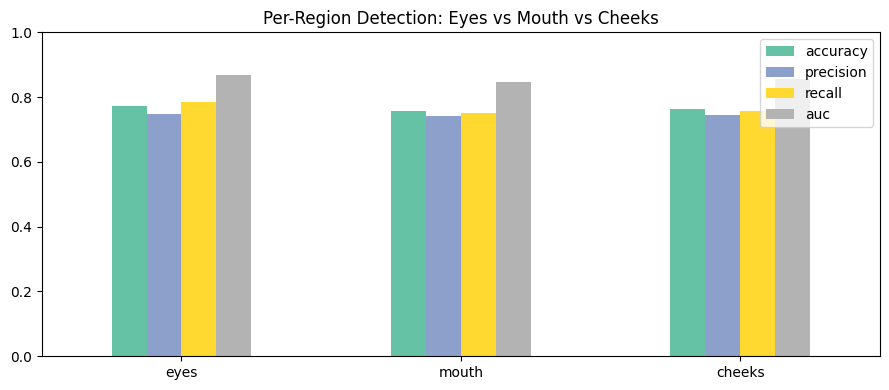


✅ S2 complete


In [ ]:
df_reg = pd.read_csv(DIRS['metrics']/'region_frames.csv')

tf_r = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

region_results = {}
for region in ['eyes', 'mouth', 'cheeks']:
    print(f'\n=== {region} ===')
    dr    = df_reg[df_reg.region == region]
    tr_ld = DataLoader(FrameDS(dr[dr.split=='train'], tf_r), 64, shuffle=True,  num_workers=4, pin_memory=True)
    te_ld = DataLoader(FrameDS(dr[dr.split=='test'],  tf_r), 64, shuffle=False, num_workers=4, pin_memory=True)

    model   = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2).to(DEVICE)
    opt     = torch.optim.AdamW(model.parameters(), lr=3e-4)
    sched   = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4, steps_per_epoch=len(tr_ld), epochs=5)
    loss_fn = nn.CrossEntropyLoss()
    scaler  = GradScaler('cuda')

    for epoch in range(5):
        model.train()
        for x, y in tr_ld:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            with autocast('cuda'): loss = loss_fn(model(x), y)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update(); sched.step()

    m = evaluate(model, te_ld)
    region_results[region] = m
    print(f'  {region}: {m}')
    torch.save(model.state_dict(), DIRS['models']/f'efficientnet_{region}.pth')

df_rc = pd.DataFrame(region_results).T
df_rc.to_csv(DIRS['metrics']/'region_comparison.csv')

df_rc[['accuracy','precision','recall','auc']].plot(kind='bar', figsize=(9,4), colormap='Set2')
plt.title('Per-Region Detection: Eyes vs Mouth vs Cheeks')
plt.xticks(rotation=0); plt.ylim(0,1); plt.tight_layout()
plt.savefig(DIRS['metrics']/'region_plot.png', dpi=150)
plt.show()
print('\n S2 complete')

---
##  SECTION 3 — Temporal GRU Adaptive Loop

### CELL 3A — Frozen Feature Extractor

In [ ]:
class FastExtractor(nn.Module):
    def __init__(self, weights_path=None):
        super().__init__()
        self.net = timm.create_model('mobilenetv3_small_100', pretrained=True, num_classes=0)
        if weights_path and Path(weights_path).exists():
            sd = torch.load(weights_path, map_location='cpu')
            self.net.load_state_dict(
                {k: v for k, v in sd.items() if 'classifier' not in k}, strict=False)
        for p in self.parameters(): p.requires_grad = False
    def forward(self, x): return self.net(x)

EXTRACTOR = FastExtractor(DIRS['models']/'mobilenet_best.pth').to(DEVICE).eval()
with torch.no_grad():
    FEAT_DIM = EXTRACTOR(torch.zeros(1,3,224,224).to(DEVICE)).shape[1]
print(f' Extractor ready | feature dim: {FEAT_DIM}')

✅ Extractor ready | feature dim: 1024


### CELL 3B — Temporal Dataset & GRU Model

In [ ]:
class TemporalDS(Dataset):
    def __init__(self, df, seq_len=8, step=1, transform=None):
        self.tf  = transform
        self.seq = []
        for vid_id, grp in df.groupby('video_id'):
            paths   = sorted(grp['path'].tolist())
            label   = grp['label'].iloc[0]
            sampled = paths[::step]
            for s in range(0, len(sampled) - seq_len + 1, seq_len // 2):
                win = sampled[s:s+seq_len]
                if len(win) == seq_len:
                    self.seq.append((win, label))
    def __len__(self): return len(self.seq)
    def __getitem__(self, i):
        paths, label = self.seq[i]
        frames = []
        for p in paths:
            img = cv2.imread(p)
            if img is None: img = np.zeros((224,224,3), dtype=np.uint8)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if self.tf: img = self.tf(img)
            frames.append(img)
        return torch.stack(frames), label

class GRUClassifier(nn.Module):
    def __init__(self, feat_dim, hidden=128):
        super().__init__()
        self.gru = nn.GRU(feat_dim, hidden, num_layers=1, batch_first=True)
        self.fc  = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, 2))
    def forward(self, x, extractor):
        B, T, C, H, W = x.shape
        with torch.no_grad():
            with autocast('cuda'):
                feats = extractor(x.view(B*T, C, H, W).to(DEVICE))
        out, _ = self.gru(feats.float().view(B, T, -1))
        return self.fc(out[:, -1, :])

print(' GRU model defined')

✅ GRU model defined


### CELL 3C — Adaptive Loop (all metrics must reach > 85%)

In [ ]:
df = pd.read_csv(DIRS['splits']/'frames_split.csv')
tf_t = transforms.Compose([
    transforms.ToPILImage(), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

THRESHOLD = 0.85
MAX_ITER  = 15
SEQ_LEN   = 8
history   = []
best_score, best_iter = 0.0, None
b_m = {}

for iteration in range(1, MAX_ITER + 1):
    step = iteration
    print(f'\n=== Iter {iteration}/{MAX_ITER} | frame step={step} ===')

    tr_ds = TemporalDS(df[df.split=='train'], SEQ_LEN, step, tf_t)
    te_ds = TemporalDS(df[df.split=='test'],  SEQ_LEN, step, tf_t)
    if len(tr_ds) < 10: print('  Too few sequences, stopping'); break

    tr_ld = DataLoader(tr_ds, 32, shuffle=True,  num_workers=4, pin_memory=True)
    te_ld = DataLoader(te_ds, 32, shuffle=False, num_workers=4, pin_memory=True)

    model   = GRUClassifier(FEAT_DIM).to(DEVICE)
    opt     = torch.optim.AdamW(model.parameters(), lr=1e-3)
    sched   = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3,
                  steps_per_epoch=len(tr_ld), epochs=6)
    loss_fn = nn.CrossEntropyLoss()
    scaler  = GradScaler('cuda')

    for epoch in range(6):
        model.train()
        for x, y in tr_ld:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            with autocast('cuda'): loss = loss_fn(model(x, EXTRACTOR), y)
            scaler.scale(loss).backward()
            scaler.step(opt); scaler.update(); sched.step()

    model.eval()
    preds, probs, targets = [], [], []
    with torch.no_grad():
        for x, y in te_ld:
            with autocast('cuda'):
                out = torch.softmax(model(x.to(DEVICE), EXTRACTOR), dim=1)
            preds   += out.argmax(1).cpu().tolist()
            probs   += out[:,1].cpu().tolist()
            targets += y.tolist()

    try: _auc = roc_auc_score(targets, probs)
    except ValueError: _auc = 0.5

    m = {
        'iteration': iteration, 'step': step,
        'accuracy':  round(accuracy_score(targets, preds), 4),
        'precision': round(precision_score(targets, preds, zero_division=0), 4),
        'recall':    round(recall_score(targets, preds, zero_division=0), 4),
        'auc':       round(_auc, 4)
    }
    history.append(m)
    print(f'  acc={m["accuracy"]} prec={m["precision"]} rec={m["recall"]} auc={m["auc"]}')

    idir = DIRS['temporal'] / f'iter_{iteration:02d}_step{step}'
    idir.mkdir(exist_ok=True)
    torch.save(model.state_dict(), idir/'gru_model.pth')
    with open(idir/'metrics.json','w') as f: json.dump(m, f, indent=2)

    score = min(m['accuracy'], m['precision'], m['recall'], m['auc'])
    if score > best_score:
        best_score = score
        best_iter  = (iteration, idir, m)
        b_m = m

    if all(m[k] >= THRESHOLD for k in ['accuracy','precision','recall','auc']):
        print(f'\n TARGET REACHED at iteration {iteration}!')
        break
    else:
        below = [f'{k}={m[k]}' for k in ['accuracy','precision','recall','auc'] if m[k] < THRESHOLD]
        print(f'  Still below 0.85: {below}')

print('\n Adaptive loop complete')


=== Iter 1/15 | frame step=1 ===
  acc=0.7575 prec=0.7441 rec=0.785 auc=0.8621
  Still below 0.85: ['accuracy=0.7575', 'precision=0.7441', 'recall=0.785']

=== Iter 2/15 | frame step=2 ===
  acc=0.755 prec=0.7429 rec=0.78 auc=0.8654
  Still below 0.85: ['accuracy=0.755', 'precision=0.7429', 'recall=0.78']

=== Iter 3/15 | frame step=3 ===
  Too few sequences, stopping

✅ Adaptive loop complete


### CELL 3D — Save Best, Plot & Download

Best iteration: 1
Best metrics:   {'iteration': 1, 'step': 1, 'accuracy': 0.7575, 'precision': 0.7441, 'recall': 0.785, 'auc': np.float64(0.8621)}


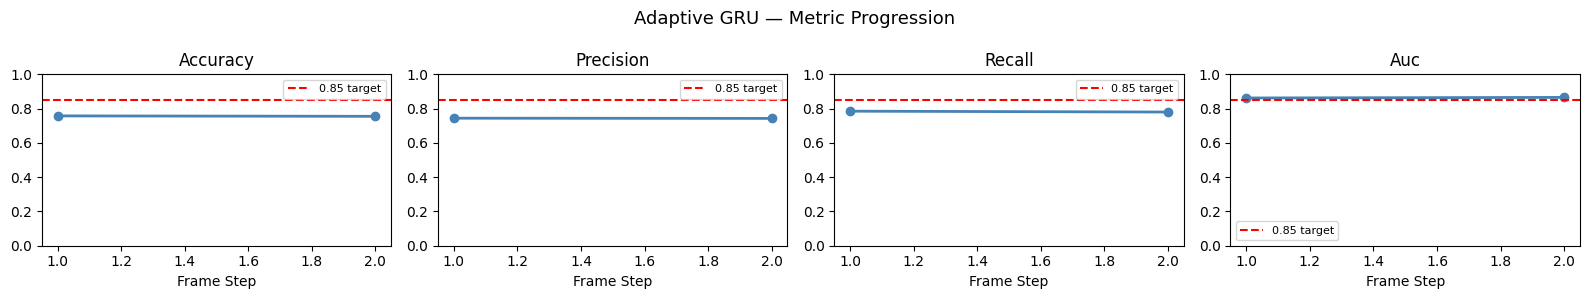


✅ All done!
📥 Download: /content/pipeline_outputs.zip


In [ ]:
b_m = b_m if b_m else {}
df_hist = pd.DataFrame(history)
df_hist.to_csv(DIRS['temporal']/'history.csv', index=False)

if best_iter:
    b_iter, b_dir, b_m = best_iter
    shutil.copytree(str(b_dir), str(DIRS['temporal_best']), dirs_exist_ok=True)
    with open(DIRS['temporal_best']/'BEST_SUMMARY.json','w') as f:
        json.dump({
            'best_iteration': b_iter, 'metrics': b_m,
            'threshold_reached': all(b_m[k] >= 0.85
                for k in ['accuracy','precision','recall','auc'])
        }, f, indent=2)
    print('Best iteration:', b_iter)
    print('Best metrics:  ', b_m)

if len(df_hist) > 0:
    fig, axes = plt.subplots(1, 4, figsize=(16, 3))
    for ax, metric in zip(axes, ['accuracy','precision','recall','auc']):
        ax.plot(df_hist['step'], df_hist[metric], marker='o', linewidth=2, color='steelblue')
        ax.axhline(0.85, color='red', linestyle='--', label='0.85 target')
        ax.set_title(metric.capitalize()); ax.set_xlabel('Frame Step')
        ax.set_ylim(0, 1); ax.legend(fontsize=8)
    plt.suptitle('Adaptive GRU — Metric Progression', fontsize=13)
    plt.tight_layout()
    plt.savefig(DIRS['temporal']/'temporal_curve.png', dpi=150)
    plt.show()

report = {
    's1': pd.read_csv(DIRS['metrics']/'s1_results.csv').to_dict(),
    's2': pd.read_csv(DIRS['metrics']/'region_comparison.csv').to_dict(),
    's3_best': b_m,
    's3_history': df_hist.to_dict()
}
with open(DIRS['final']/'report.json','w') as f:
    json.dump(report, f, indent=2)

shutil.make_archive('/content/pipeline_outputs', 'zip', '/content/outputs')
print('\n All done!')
print(' Download: /content/pipeline_outputs.zip')

In [ ]:
import shutil
shutil.make_archive('/content/pipeline_outputs', 'zip', '/content/outputs')
print(' Done — download at: /content/pipeline_outputs.zip')

✅ Done — download at: /content/pipeline_outputs.zip
